Tarea: Proponer un metodo para distribuir k centroides en la
Imagen (El Astronomo, 0000405625_OG.JPG) de tal forma que la imagen obtenida a
partir de los Centroides sea lo mas parecida A la imagen original
¿Que funcion de distancia utiizaras para comparar la imagen original
Con la obtenida por el metodo (teselacion de Voronoi)?

the "image compression" should work as follows: k representative points (with an alogrithm of your choice, considering the color and the positions of the points to be most representative) are chosen and a voronoi partition is created to represent the image as well as possible. the voroni partition contains only the representative points, that dictate the voronoi partition and their colors. graph that partition.

make sure the approach you choose is computationally efficient for k = 10, 50, 100, 1000, 10000 representative points.

the represenatatiev points should be selected by position and color, and the compressed image should be a voronoi diagram with k representative points (position and color). make sure to choose an approach that makes sure to select the most representaive points for a image compressed in a vornoi partition. output the partition in the end. make sure the output image shows the points, and the colored voronoi partitions

Processing k=10...
MSE for k=10: 1587.08


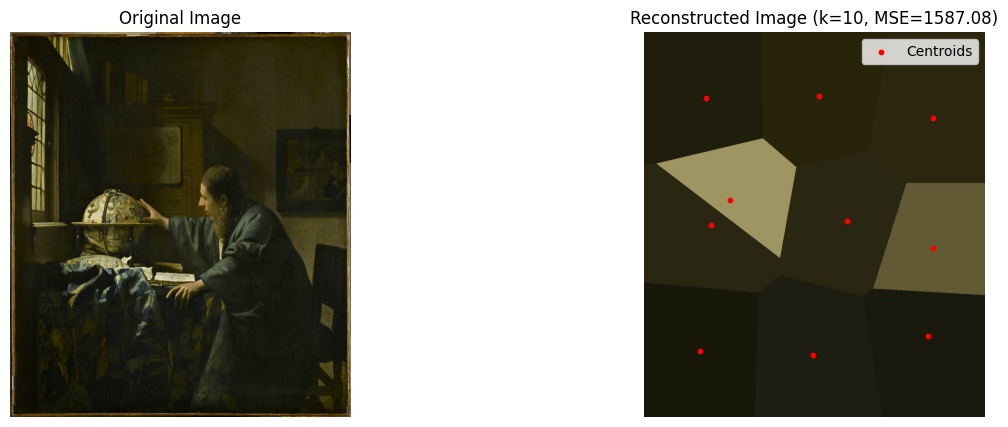

Processing k=50...


KeyboardInterrupt: 

In [ ]:
import numpy as np
import cv2
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the image
def load_image(image_path):
    # Load the image using OpenCV (BGR format)
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image could not be loaded. Check the file path.")
    # Convert from BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# Step 2: Prepare data for k-means (5D: x, y, R, G, B)
def prepare_data(img):
    height, width, _ = img.shape
    # Create coordinate arrays
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    # Normalize coordinates and colors
    x_norm = x / width
    y_norm = y / height
    colors = img / 255.0  # Normalize RGB values to [0, 1]
    # Flatten into a (height*width, 5) array
    data = np.stack([x_norm.ravel(), y_norm.ravel(),
                     colors[:, :, 0].ravel(),  # R
                     colors[:, :, 1].ravel(),  # G
                     colors[:, :, 2].ravel()], axis=1)  # B
    return data, height, width

# Step 3: Apply k-means to find centroids
def compute_centroids(data, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)
    centroids = kmeans.cluster_centers_
    return centroids

# Step 4: Reconstruct image using Voronoi tessellation
def reconstruct_image(centroids, height, width):
    # Create grid of pixel coordinates
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    coords = np.stack([x.ravel(), y.ravel()], axis=1)
    
    # Extract centroid positions (not normalized)
    centroid_positions = centroids[:, :2] * np.array([width, height])
    # Extract centroid colors (not normalized)
    centroid_colors = centroids[:, 2:] * 255.0
    
    # Compute distances from each pixel to all centroids
    distances = np.zeros((height * width, len(centroids)))
    for i, centroid in enumerate(centroid_positions):
        distances[:, i] = np.sum((coords - centroid) ** 2, axis=1)
    
    # Assign each pixel to the nearest centroid
    labels = np.argmin(distances, axis=1)
    # Create reconstructed image
    reconstructed = np.zeros((height * width, 3))
    for i in range(len(centroids)):
        reconstructed[labels == i] = centroid_colors[i]
    
    return reconstructed.reshape(height, width, 3), centroid_positions

# Step 5: Compute MSE between original and reconstructed images
def compute_mse(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    return mse

# Step 6: Visualize the result
def visualize_result(original, reconstructed, centroids, k):
    plt.figure(figsize=(15, 5))
    
    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(original.astype(np.uint8))
    plt.title("Original Image")
    plt.axis('off')
    
    # Reconstructed image with centroids
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed.astype(np.uint8))
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=10, label='Centroids')
    plt.title(f"Reconstructed Image (k={k}, MSE={compute_mse(original, reconstructed):.2f})")
    plt.axis('off')
    plt.legend()
    
    plt.show()

# Main function to run the compression
def voronoi_image_compression(image_path, k):
    # Load and preprocess
    img = load_image(image_path)
    data, height, width = prepare_data(img)
    
    # Compute centroids
    centroids = compute_centroids(data, k)
    
    # Reconstruct image
    reconstructed, centroid_positions = reconstruct_image(centroids, height, width)
    
    # Compute MSE
    mse = compute_mse(img, reconstructed)
    print(f"MSE for k={k}: {mse:.2f}")
    
    # Visualize
    visualize_result(img, reconstructed, centroid_positions, k)
    
    return reconstructed, centroid_positions

# Example usage
if __name__ == "__main__":
    # Replace with the actual path to "El Astronomo, 0000405625_OG.JPG"
    image_path = "0000405625_OG.JPG"  # Update this path
    k_values = [10, 50, 100, 1000]  # Test with different k values (up to 1000 for speed)
    
    for k in k_values:
        print(f"Processing k={k}...")
        voronoi_image_compression(image_path, k)